imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.impute import SimpleImputer

#CARREGAR E PREPARAR OS DADOS

In [9]:
df = pd.read_csv('diabetes.csv.xls')
cols_com_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_com_zero] = df[cols_com_zero].replace(0, np.nan)
imputer = SimpleImputer(strategy='median')
df[cols_com_zero] = imputer.fit_transform(df[cols_com_zero])

X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [4]:
#CONFIGURAÇÕES A TESTAR

In [5]:
criterions = ['gini', 'entropy', 'log_loss']
splitters = ['best', 'random']
test_sizes = [0.2, 0.3, 0.4]
resultados = []

#VARREDURA COMPLETA

In [6]:
for crit in criterions:
    for split in splitters:
        for ts in test_sizes:
            X_treino, X_teste, y_treino, y_teste = train_test_split(
                X, y, test_size=ts, random_state=42
            )
            modelo = DecisionTreeClassifier(
                criterion=crit,
                splitter=split,
                random_state=42
            )
            modelo.fit(X_treino, y_treino)
            y_pred = modelo.predict(X_teste)

            resultados.append({
                'criterion': crit,
                'splitter': split,
                'test_size': ts,
                'Acurácia': metrics.accuracy_score(y_teste, y_pred),
                'Precisão': metrics.precision_score(y_teste, y_pred, zero_division=0),
                'Recall': metrics.recall_score(y_teste, y_pred, zero_division=0),
                'F1-score': metrics.f1_score(y_teste, y_pred, zero_division=0)
            })

# DataFrame completo

In [7]:
df_res = pd.DataFrame(resultados)

print("="*70)
print("TABELA COMPLETA – Todas as combinações testadas")
print("="*70)
print(df_res.to_string(index=False))

TABELA COMPLETA – Todas as combinações testadas
criterion splitter  test_size  Acurácia  Precisão   Recall  F1-score
     gini     best        0.2  0.720779  0.603448 0.636364  0.619469
     gini     best        0.3  0.696970  0.558140 0.600000  0.578313
     gini     best        0.4  0.685065  0.521368 0.598039  0.557078
     gini   random        0.2  0.701299  0.573770 0.636364  0.603448
     gini   random        0.3  0.658009  0.505376 0.587500  0.543353
     gini   random        0.4  0.681818  0.516393 0.617647  0.562500
  entropy     best        0.2  0.720779  0.603448 0.636364  0.619469
  entropy     best        0.3  0.714286  0.579545 0.637500  0.607143
  entropy     best        0.4  0.746753  0.605263 0.676471  0.638889
  entropy   random        0.2  0.701299  0.569231 0.672727  0.616667
  entropy   random        0.3  0.683983  0.541176 0.575000  0.557576
  entropy   random        0.4  0.704545  0.545455 0.647059  0.591928
 log_loss     best        0.2  0.720779  0.603448 0.636

#FUNÇÕES AUXILIARES

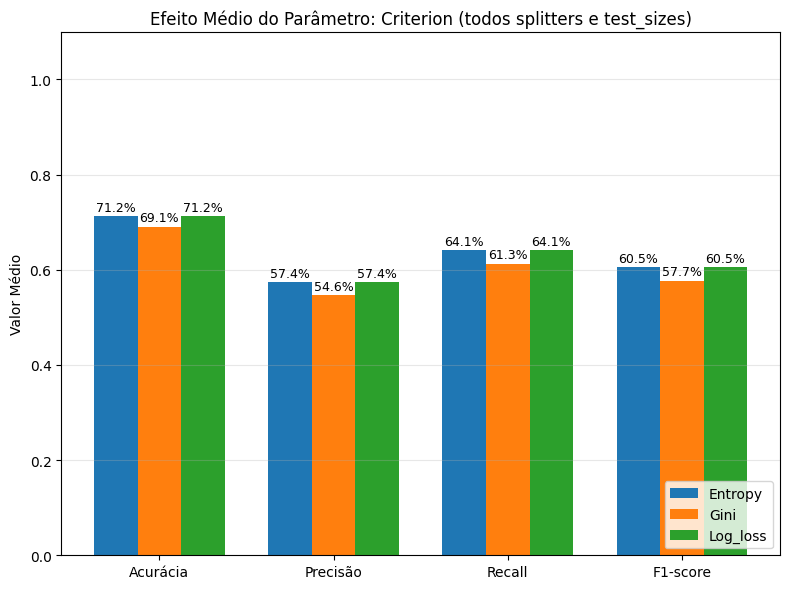

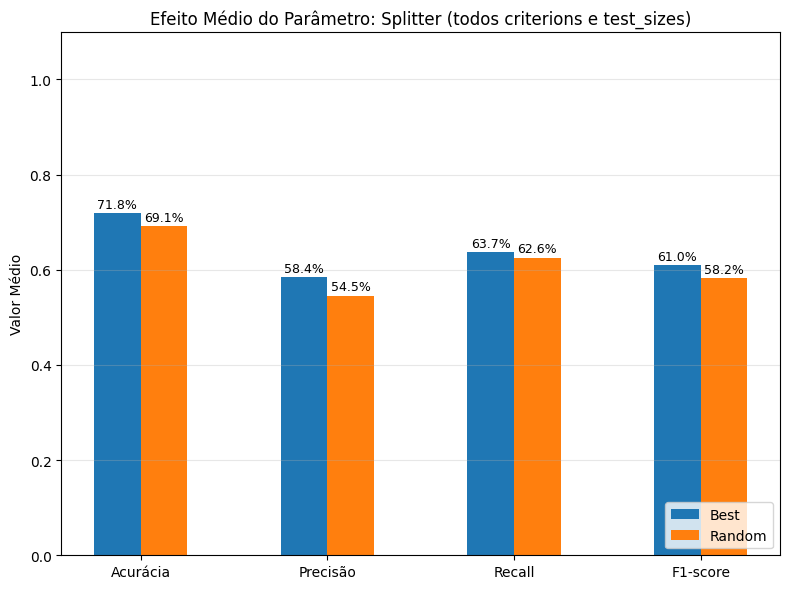

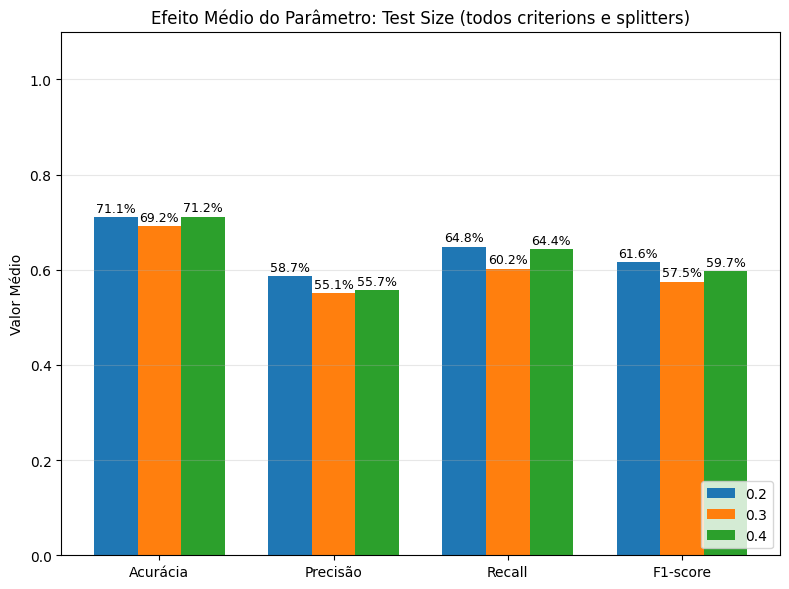


MELHOR COMBINAÇÃO (pelo F1-score):
criterion: entropy, splitter: best, test_size: 0.4
Acurácia: 0.7468 (74.68%)
Precisão: 0.6053 (60.53%)
Recall:   0.6765 (67.65%)
F1-score: 0.6389 (63.89%)


In [8]:
def adicionar_rotulos(bars, ax):
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height*100:.1f}%', ha='center', va='bottom', fontsize=9)

def plot_efeito_medio(col_param, titulo):
    
    metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-score']
    medias = df_res.groupby(col_param)[metricas].mean()
    x = np.arange(len(metricas))
    largura = 0.25
    fig, ax = plt.subplots(figsize=(8, 6))
    for i, (rotulo, linha) in enumerate(medias.iterrows()):
        barras = ax.bar(x + i*largura, linha.values, largura, label=str(rotulo).capitalize())
        adicionar_rotulos(barras, ax)
    ax.set_xticks(x + largura * (len(medias)-1)/2)
    ax.set_xticklabels(metricas)
    ax.set_ylabel('Valor Médio')
    ax.set_title(f'Efeito Médio do Parâmetro: {titulo}')
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


#GRÁFICOS DE EFEITO MÉDIO

plot_efeito_medio('criterion', 'Criterion (todos splitters e test_sizes)')
plot_efeito_medio('splitter', 'Splitter (todos criterions e test_sizes)')
plot_efeito_medio('test_size', 'Test Size (todos criterions e splitters)')


#DESTAQUE: MELHOR COMBINAÇÃO GERAL

melhor = df_res.loc[df_res['F1-score'].idxmax()]  
print("\n" + "="*70)
print("MELHOR COMBINAÇÃO (pelo F1-score):")
print("="*70)
print(f"criterion: {melhor['criterion']}, splitter: {melhor['splitter']}, test_size: {melhor['test_size']}")
print(f"Acurácia: {melhor['Acurácia']:.4f} ({melhor['Acurácia']*100:.2f}%)")
print(f"Precisão: {melhor['Precisão']:.4f} ({melhor['Precisão']*100:.2f}%)")
print(f"Recall:   {melhor['Recall']:.4f} ({melhor['Recall']*100:.2f}%)")
print(f"F1-score: {melhor['F1-score']:.4f} ({melhor['F1-score']*100:.2f}%)")